# 1. Basic

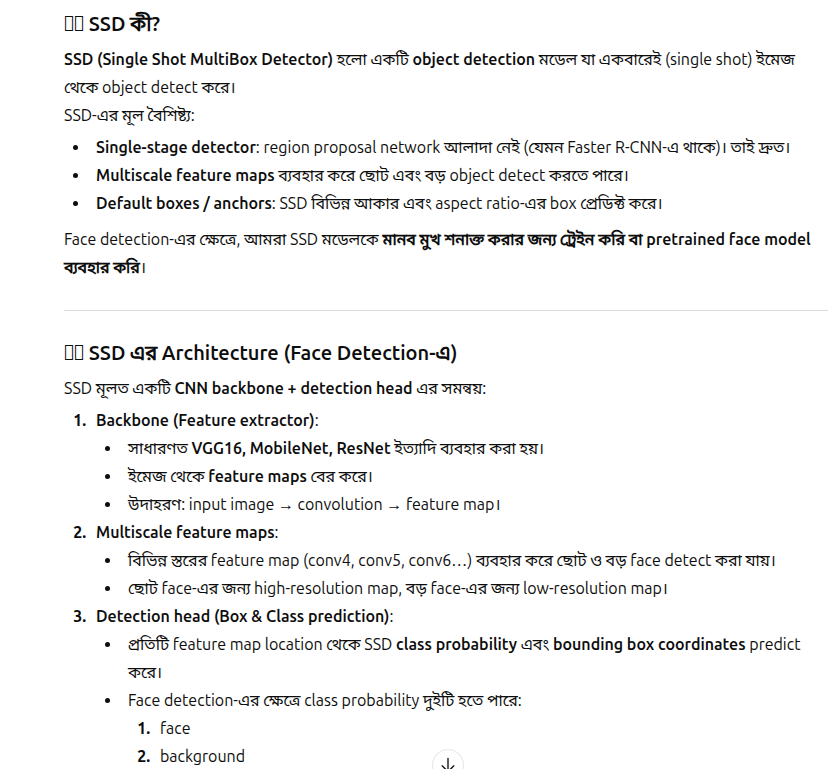

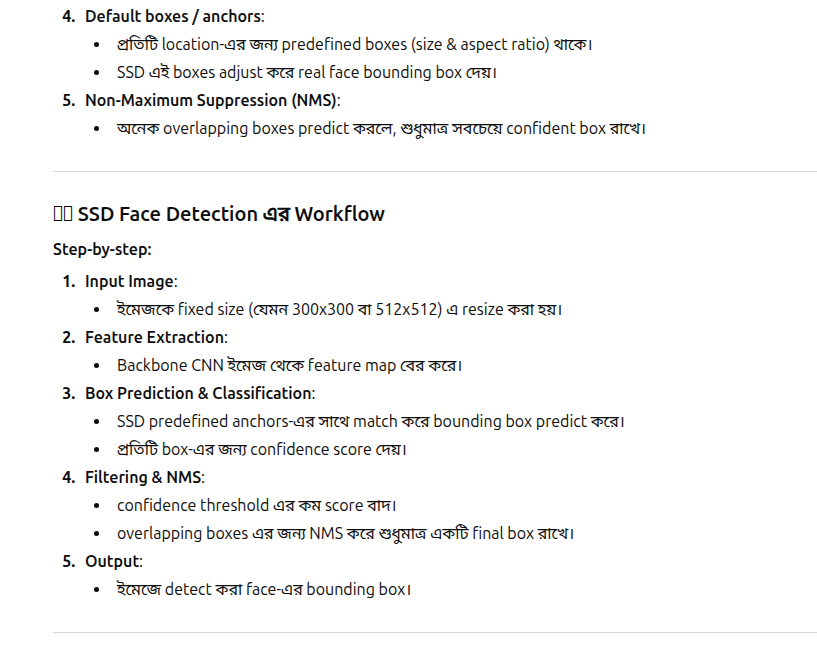

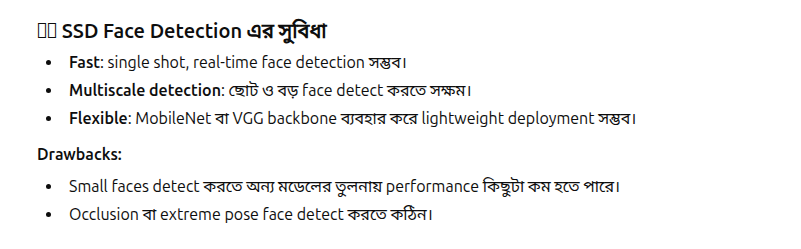

**Note : TensorFlow Hub-এর SSD MobileNet V2 ব্যবহার করবো।**

# 1. Individual Image Detection (TF SSD)

In [ ]:
import cv2
import tensorflow as tf
import tensorflow_hub as hub

# Load pretrained SSD face detection model
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1")

# Load image
image_path = "../dataset/test/bellingham.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
input_tensor = tf.convert_to_tensor(image_rgb)
input_tensor = tf.image.resize(input_tensor, (320, 320))
input_tensor = input_tensor[tf.newaxis, ...]

# Run detection
detections = model(input_tensor)

boxes = detections['detection_boxes'][0].numpy()
scores = detections['detection_scores'][0].numpy()

height, width, _ = image.shape
for i in range(len(scores)):
    if scores[i] > 0.5:
        ymin, xmin, ymax, xmax = boxes[i]
        x1, y1, x2, y2 = int(xmin*width), int(ymin*height), int(xmax*width), int(ymax*height)
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

cv2.imshow("Face Detection - Image", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

# 2. Video Face Detection

In [ ]:
import cv2
import tensorflow as tf
import tensorflow_hub as hub

# Load model
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1")

# Load video
video_path = "../dataset/vid/s.mp4"
cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_tensor = tf.convert_to_tensor(image_rgb)
    input_tensor = tf.image.resize(input_tensor, (320, 320))
    input_tensor = input_tensor[tf.newaxis, ...]
    
    detections = model(input_tensor)
    boxes = detections['detection_boxes'][0].numpy()
    scores = detections['detection_scores'][0].numpy()
    
    h, w, _ = frame.shape
    for i in range(len(scores)):
        if scores[i] > 0.5:
            ymin, xmin, ymax, xmax = boxes[i]
            x1, y1, x2, y2 = int(xmin*w), int(ymin*h), int(xmax*w), int(ymax*h)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    cv2.imshow("Face Detection - Video", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # Press Esc to stop
        break

cap.release()
cv2.destroyAllWindows()

# 3. Webcam Face Detection

In [ ]:
import cv2
import tensorflow as tf
import tensorflow_hub as hub

# Load model
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1")

# Open webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_tensor = tf.convert_to_tensor(image_rgb)
    input_tensor = tf.image.resize(input_tensor, (320, 320))
    input_tensor = input_tensor[tf.newaxis, ...]
    
    detections = model(input_tensor)
    boxes = detections['detection_boxes'][0].numpy()
    scores = detections['detection_scores'][0].numpy()
    
    h, w, _ = frame.shape
    for i in range(len(scores)):
        if scores[i] > 0.5:
            ymin, xmin, ymax, xmax = boxes[i]
            x1, y1, x2, y2 = int(xmin*w), int(ymin*h), int(xmax*w), int(ymax*h)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    cv2.imshow("Face Detection - Webcam", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # Press Esc to exit
        break

cap.release()
cv2.destroyAllWindows()

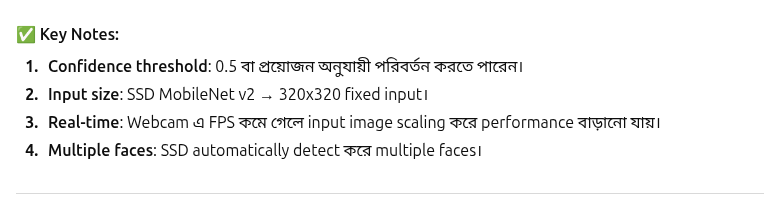